# CD-A no-epoch: baseline vs weak-faithfulness variants on ER graphs

Benchmarks `coordinate0.dag_coordinate_descent_l0` (cd_A_noepoch) against
`cd_A_weakfaith.dag_coordinate_descent_l0_weakfaith` under several
(`screening`, `faithfulness_tau`, `sampling_mode`) configurations on random
ER graphs with Gaussian noise.

Design doc: `docs/weak_faithfulness_cd_A_noepoch_zh.md`.

Metrics: SHD, CPDAG-SHD, MEC match, runtime, actual steps (when
early-stopped), and the mask sparsity $M / d(d-1)$ kept by the screening.

In [2]:
# 1) Environment and imports
import os
import sys
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_noepoch_fit
from coordinate_descent.cd_A_weakfaith import (
    dag_coordinate_descent_l0_weakfaith as cd_noepoch_weakfaith_fit,
    _build_faithfulness_mask,
)

try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)

print('cd_A baseline  : OK')
print('cd_A weakfaith : OK')

Python   : 3.10.11
Repo root: c:\Users\super\DAG
CPDAG-SHD backend unavailable (fallback): No module named 'GPUtil'
cd_A baseline  : OK
cd_A weakfaith : OK


In [3]:
# 2) Helpers
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est,
             actual_steps=None, mask_keep_ratio=None, extra=None):
    mec = int(is_in_markov_equiv_class(G_true, G_est))
    shd = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    row = {
        'd': d,
        'n_samples': n,
        'trial_id': trial_id,
        'seed': seed,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }
    if actual_steps is not None:
        row['actual_steps'] = int(actual_steps)
    if mask_keep_ratio is not None:
        row['mask_keep_ratio'] = float(mask_keep_ratio)
    if extra:
        row.update(extra)
    return row


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
        agg_dict['actual_steps_min'] = ('actual_steps', 'min')
        agg_dict['actual_steps_max'] = ('actual_steps', 'max')
    if 'mask_keep_ratio' in df.columns:
        agg_dict['mask_keep_ratio_mean'] = ('mask_keep_ratio', 'mean')
    return (
        df.groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(**agg_dict)
    )


def iter_trials(cfg: dict):
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = SyntheticDataset(
                    n=n,
                    d=d,
                    graph_type='ER',
                    degree=cfg['degree'],
                    noise_type=cfg['noise_type'],
                    B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X = dataset.X
                S = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


print('Helpers ready.')

Helpers ready.


In [4]:
# 3) Config
CFG = {
    'trials': 10,
    'seed': 42,
    'd_list': [20, 30, 50],
    'n_list': [20000],
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    'T': 100000,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'er_cd_A_weakfaith_benchmark',
    # --- Early-stopping config ---
    'early_stop': True,
    'es_check_every': None,   # None -> use d*(d+1)//2
    'es_tol': 1e-4,
    'es_patience': 10,
    'es_min_steps': None,     # None -> use check_every*10
}
os.makedirs(CFG['out_dir'], exist_ok=True)

# Algorithm variants to benchmark. The baseline (tau=0) uses coordinate0's
# dag_coordinate_descent_l0 directly; all others go through the weakfaith
# variant with different (screening, tau, sampling_mode) settings.
VARIANTS = [
    {'label': 'baseline',                 'kind': 'baseline'},
    {'label': 'wf_corr_tau0.02_preserve', 'kind': 'weakfaith',
     'screening': 'corr',  'tau': 0.02, 'sampling_mode': 'preserve'},
    {'label': 'wf_corr_tau0.05_preserve', 'kind': 'weakfaith',
     'screening': 'corr',  'tau': 0.05, 'sampling_mode': 'preserve'},
    {'label': 'wf_pcorr_tau0.02_preserve', 'kind': 'weakfaith',
     'screening': 'pcorr', 'tau': 0.02, 'sampling_mode': 'preserve'},
    {'label': 'wf_pcorr_tau0.05_preserve', 'kind': 'weakfaith',
     'screening': 'pcorr', 'tau': 0.05, 'sampling_mode': 'preserve'},
    {'label': 'wf_corr_tau0.05_pool',     'kind': 'weakfaith',
     'screening': 'corr',  'tau': 0.05, 'sampling_mode': 'pool'},
]

print('Config ready.')
print(f"  d_list      : {CFG['d_list']}")
print(f"  n_list      : {CFG['n_list']}")
print(f"  trials      : {CFG['trials']}")
print(f"  lambda_l0   : {CFG['lambda_l0']}")
print(f"  T (budget)  : {CFG['T']}")
print(f"  early_stop  : {CFG['early_stop']} (tol={CFG['es_tol']}, patience={CFG['es_patience']})")
print(f"  variants    : {len(VARIANTS)}")
for v in VARIANTS:
    print(f"    - {v['label']}")

Config ready.
  d_list      : [20, 30, 50]
  n_list      : [20000]
  trials      : 10
  lambda_l0   : 0.2
  T (budget)  : 100000
  early_stop  : True (tol=0.0001, patience=10)
  variants    : 6
    - baseline
    - wf_corr_tau0.02_preserve
    - wf_corr_tau0.05_preserve
    - wf_pcorr_tau0.02_preserve
    - wf_pcorr_tau0.05_preserve
    - wf_corr_tau0.05_pool


In [5]:
# 4) Run all variants on the same trials
rows = []
skip_logs = []

for d, n, trial_id, seed, X, S, G_true in iter_trials(CFG):
    # Precompute mask keep ratios for diagnostic logging (one per screening x tau).
    keep_cache = {}
    for v in VARIANTS:
        if v['kind'] != 'weakfaith':
            continue
        key = (v['screening'], v['tau'])
        if key not in keep_cache:
            try:
                _, M = _build_faithfulness_mask(S, v['tau'], v['screening'])
                keep_cache[key] = M / (d * (d - 1))
            except ValueError as e:
                keep_cache[key] = None  # all masked

    for v in VARIANTS:
        label = v['label']
        try:
            t0 = time.perf_counter()
            if v['kind'] == 'baseline':
                result = cd_noepoch_fit(
                    S=S, T=CFG['T'], seed=seed,
                    threshold=CFG['threshold'], lambda_l0=CFG['lambda_l0'],
                    early_stop=CFG['early_stop'], check_every=CFG['es_check_every'],
                    tol=CFG['es_tol'], patience=CFG['es_patience'],
                    min_steps=CFG['es_min_steps'],
                    return_history=CFG['early_stop'],
                )
                keep_ratio = 1.0
            else:
                key = (v['screening'], v['tau'])
                keep_ratio = keep_cache.get(key)
                if keep_ratio is None:
                    raise ValueError(f"mask fully empty for {key}")
                result = cd_noepoch_weakfaith_fit(
                    S=S, T=CFG['T'], seed=seed,
                    threshold=CFG['threshold'], lambda_l0=CFG['lambda_l0'],
                    early_stop=CFG['early_stop'], check_every=CFG['es_check_every'],
                    tol=CFG['es_tol'], patience=CFG['es_patience'],
                    min_steps=CFG['es_min_steps'],
                    return_history=CFG['early_stop'],
                    faithfulness_tau=v['tau'],
                    sampling_mode=v['sampling_mode'],
                    screening=v['screening'],
                )
            rt = time.perf_counter() - t0

            if CFG['early_stop']:
                _, G_est, _, history = result
                actual_steps = len(history)
            else:
                _, G_est, _ = result
                actual_steps = None

            row = make_row(d, n, trial_id, seed, label, rt, G_true, G_est,
                           actual_steps=actual_steps, mask_keep_ratio=keep_ratio)
            rows.append(row)
            steps_str = f"  steps={actual_steps}" if actual_steps is not None else ''
            keep_str = f"  keep={keep_ratio:.2f}" if keep_ratio is not None else ''
            print(
                f'[{label:30s}] d={d} n={n} trial={trial_id}  '
                f'mec={row["mec_match"]}  shd={row["shd"]:.0f}  '
                f'cpdag_shd={row["cpdag_shd"]:.0f}  '
                f'rt={rt:.3f}s{steps_str}{keep_str}'
            )
        except Exception as e:
            skip_logs.append({'algorithm': label, 'd': d, 'n_samples': n,
                              'trial_id': trial_id, 'reason': str(e)})
            print(f'[SKIP] {label} d={d} n={n} trial={trial_id}: {e}')

df_trials = pd.DataFrame(rows)
df_summary = summarize(df_trials)

print('\nPer-(algorithm, d, n) summary:')
display(df_summary)

[baseline                      ] d=20 n=20000 trial=1  mec=0  shd=16  cpdag_shd=33  rt=3.405s  steps=11970  keep=1.00
[wf_corr_tau0.02_preserve      ] d=20 n=20000 trial=1  mec=0  shd=5  cpdag_shd=9  rt=3.220s  steps=13650  keep=0.27
[wf_corr_tau0.05_preserve      ] d=20 n=20000 trial=1  mec=0  shd=4  cpdag_shd=6  rt=3.626s  steps=13440  keep=0.26
[wf_pcorr_tau0.02_preserve     ] d=20 n=20000 trial=1  mec=0  shd=2  cpdag_shd=3  rt=3.709s  steps=12810  keep=0.22
[wf_pcorr_tau0.05_preserve     ] d=20 n=20000 trial=1  mec=0  shd=2  cpdag_shd=3  rt=3.523s  steps=12180  keep=0.19
[wf_corr_tau0.05_pool          ] d=20 n=20000 trial=1  mec=0  shd=10  cpdag_shd=16  rt=1.819s  steps=7350  keep=0.26
[baseline                      ] d=20 n=20000 trial=2  mec=0  shd=10  cpdag_shd=17  rt=3.026s  steps=11550  keep=1.00
[wf_corr_tau0.02_preserve      ] d=20 n=20000 trial=2  mec=0  shd=9  cpdag_shd=14  rt=1.971s  steps=8820  keep=0.37
[wf_corr_tau0.05_preserve      ] d=20 n=20000 trial=2  mec=0  shd=3

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,actual_steps_min,actual_steps_max,mask_keep_ratio_mean
0,baseline,20,20000,0.1,9.9,17.4,3.205544,10,12096.0,6510,21840,1.000000
1,baseline,30,20000,0.0,26.0,53.2,14.283845,10,43152.0,20925,67890,1.000000
2,baseline,50,20000,0.0,32.9,64.9,50.309948,10,86592.5,57375,100000,1.000000
3,wf_corr_tau0.02_preserve,20,20000,0.3,9.0,17.6,2.436139,10,10563.0,6720,15960,0.283158
4,wf_corr_tau0.02_preserve,30,20000,0.0,17.8,35.2,9.210653,10,31806.0,14415,41385,0.250805
5,wf_corr_tau0.02_preserve,50,20000,0.0,23.5,45.6,42.607729,10,81747.5,49725,100000,0.146204
6,wf_corr_tau0.05_pool,20,20000,0.1,11.3,20.4,1.360527,10,6426.0,3990,9450,0.272632
7,wf_corr_tau0.05_pool,30,20000,0.0,17.1,31.2,4.705445,10,16879.5,8835,34410,0.247126
8,wf_corr_tau0.05_pool,50,20000,0.0,28.1,48.0,16.118323,10,32767.5,24225,54825,0.139102
9,wf_corr_tau0.05_preserve,20,20000,0.2,7.7,16.5,2.559564,10,10794.0,6720,18060,0.272632


=== Actual steps used (mean +/- std) ===
  baseline                        d= 20  steps:    12096 +/-    5444  (budget=100000)
  baseline                        d= 30  steps:    43152 +/-   12895  (budget=100000)
  baseline                        d= 50  steps:    86592 +/-   18324  (budget=100000)
  wf_corr_tau0.02_preserve        d= 20  steps:    10563 +/-    3197  (budget=100000)
  wf_corr_tau0.02_preserve        d= 30  steps:    31806 +/-    8741  (budget=100000)
  wf_corr_tau0.02_preserve        d= 50  steps:    81748 +/-   20577  (budget=100000)
  wf_corr_tau0.05_preserve        d= 20  steps:    10794 +/-    3662  (budget=100000)
  wf_corr_tau0.05_preserve        d= 30  steps:    35294 +/-   14889  (budget=100000)
  wf_corr_tau0.05_preserve        d= 50  steps:    81110 +/-   20924  (budget=100000)
  wf_pcorr_tau0.02_preserve       d= 20  steps:    10521 +/-    3865  (budget=100000)
  wf_pcorr_tau0.02_preserve       d= 30  steps:    34642 +/-   13493  (budget=100000)
  wf_pcorr_ta

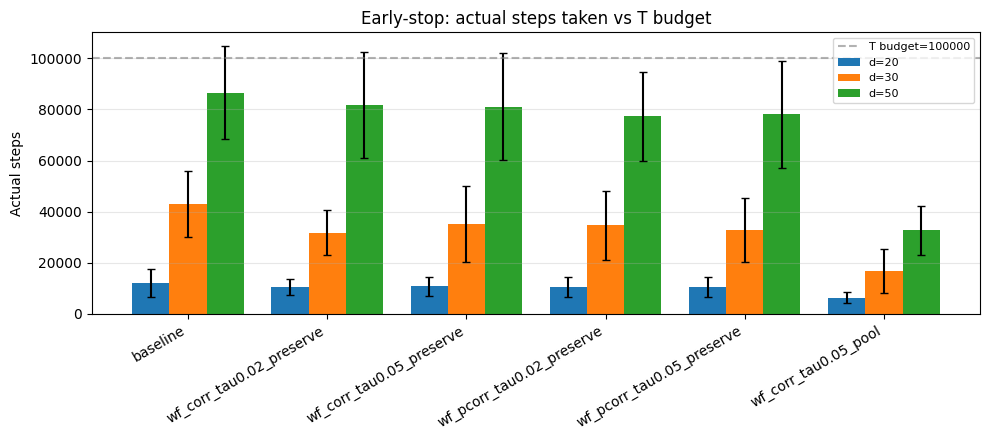

In [6]:
# 4b) Early-stop step comparison
if not CFG['early_stop'] or 'actual_steps' not in df_trials.columns:
    print('Early stopping disabled - no step data.')
else:
    algs = [v['label'] for v in VARIANTS if v['label'] in df_trials['algorithm'].unique()]
    d_vals = sorted(df_trials['d'].unique())

    print('=== Actual steps used (mean +/- std) ===')
    for alg in algs:
        for d_val in d_vals:
            s = df_trials[(df_trials['algorithm'] == alg) & (df_trials['d'] == d_val)]['actual_steps']
            if len(s) == 0:
                continue
            print(f'  {alg:30s}  d={d_val:3d}  steps: {s.mean():8.0f} +/- {s.std():7.0f}  (budget={CFG["T"]})')

    fig, ax = plt.subplots(figsize=(max(10, 1.5 * len(algs)), 4.5))
    x = np.arange(len(algs))
    width = 0.8 / max(len(d_vals), 1)
    for di, d_val in enumerate(d_vals):
        means = [df_trials[(df_trials['algorithm'] == a) & (df_trials['d'] == d_val)]['actual_steps'].mean() for a in algs]
        stds  = [df_trials[(df_trials['algorithm'] == a) & (df_trials['d'] == d_val)]['actual_steps'].std() for a in algs]
        ax.bar(x + (di - (len(d_vals)-1) / 2) * width, means, width, yerr=stds, capsize=3, label=f'd={d_val}')
    ax.axhline(CFG['T'], color='gray', linestyle='--', alpha=0.6, label=f'T budget={CFG["T"]}')
    ax.set_xticks(x)
    ax.set_xticklabels(algs, rotation=30, ha='right')
    ax.set_ylabel('Actual steps')
    ax.set_title('Early-stop: actual steps taken vs T budget')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
# 5) Save results
if len(df_trials) == 0:
    print('WARNING: no results collected.')
else:
    ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{ts_str}.csv")
    summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{ts_str}.csv")
    latest_trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv")
    latest_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv")

    df_trials.to_csv(trials_path, index=False)
    df_summary.to_csv(summary_path, index=False)
    df_trials.to_csv(latest_trials_path, index=False)
    df_summary.to_csv(latest_summary_path, index=False)

    print(f'Trials  saved to: {trials_path}')
    print(f'Summary saved to: {summary_path}')
    print(f'Rows: {len(df_trials)}  |  Skips: {len(skip_logs)}')

Trials  saved to: c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_benchmark_trials_20260418_170552.csv
Summary saved to: c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_benchmark_summary_20260418_170552.csv
Rows: 180  |  Skips: 0


In [8]:
# 6) Overall comparison (aggregated across d, n)
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df_trials.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
    if 'mask_keep_ratio' in df_trials.columns:
        agg_dict['mask_keep_mean'] = ('mask_keep_ratio', 'mean')
    order = [v['label'] for v in VARIANTS]
    df_overall = (
        df_trials.groupby('algorithm', as_index=False).agg(**agg_dict)
    )
    df_overall['algorithm'] = pd.Categorical(df_overall['algorithm'], order, ordered=True)
    df_overall = df_overall.sort_values('algorithm').reset_index(drop=True)
    display(df_overall)

,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,mask_keep_mean
0,baseline,0.033333,22.933333,45.166667,22.599779,30,47280.166667,1.000000
1,wf_corr_tau0.02_preserve,0.100000,16.766667,32.800000,18.084840,30,41372.166667,0.226722
2,wf_corr_tau0.05_preserve,0.066667,15.300000,29.366667,18.234654,30,42399.166667,0.219620
3,wf_pcorr_tau0.02_preserve,0.266667,6.100000,8.966667,18.913053,30,40803.666667,0.122408
4,wf_pcorr_tau0.05_preserve,0.366667,5.033333,8.466667,18.996026,30,40459.833333,0.117360
5,wf_corr_tau0.05_pool,0.033333,18.833333,33.200000,7.394765,30,18691.000000,0.219620


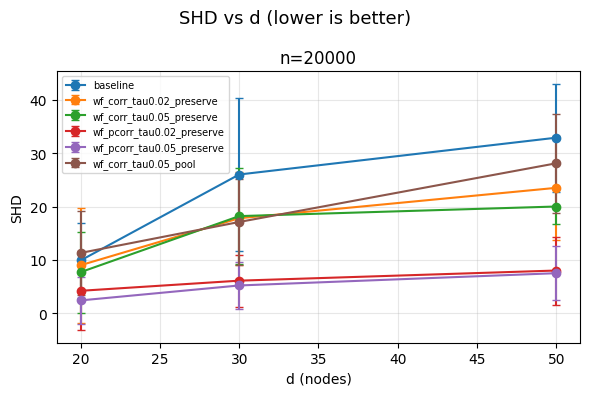

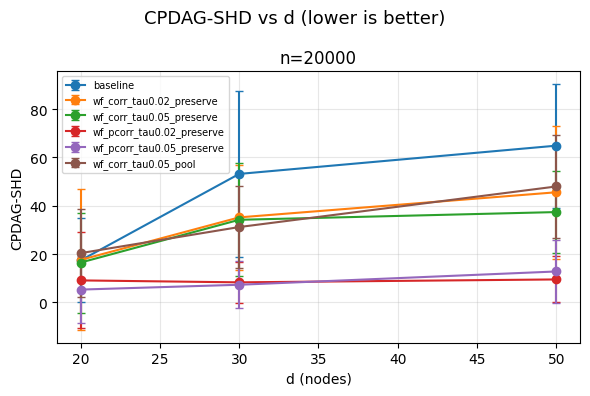

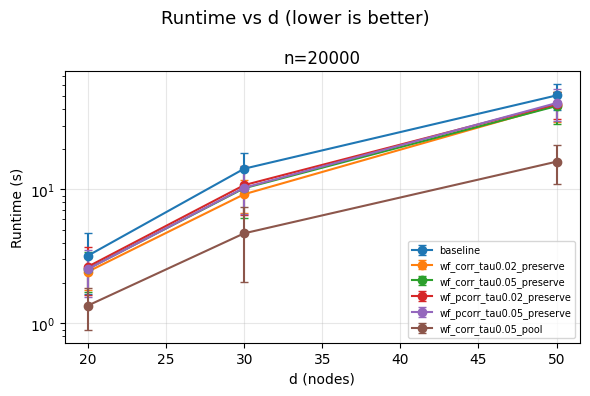

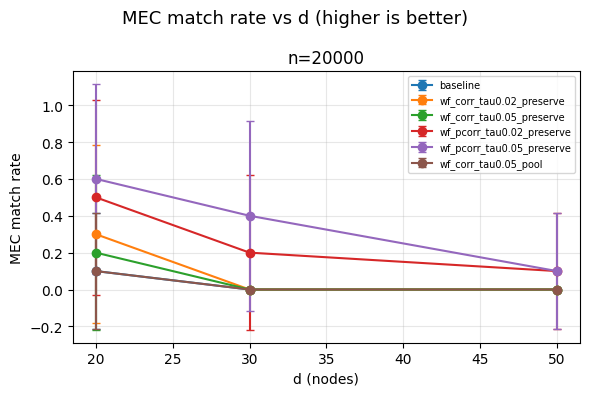

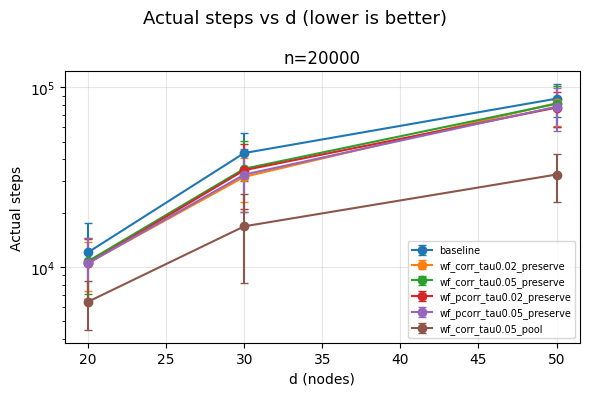

In [9]:
# 7) Plots: metric vs d across variants
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    n_vals = sorted(df_trials['n_samples'].unique())
    algs = [v['label'] for v in VARIANTS if v['label'] in df_trials['algorithm'].unique()]
    color_map = {alg: f'C{i}' for i, alg in enumerate(algs)}

    metric_specs = [
        ('shd', 'SHD', 'SHD vs d (lower is better)', False),
        ('cpdag_shd', 'CPDAG-SHD', 'CPDAG-SHD vs d (lower is better)', False),
        ('runtime_sec', 'Runtime (s)', 'Runtime vs d (lower is better)', True),
        ('mec_match', 'MEC match rate', 'MEC match rate vs d (higher is better)', False),
    ]
    if 'actual_steps' in df_trials.columns:
        metric_specs.append(('actual_steps', 'Actual steps', 'Actual steps vs d (lower is better)', True))

    for metric, ylabel, title, log_y in metric_specs:
        fig, axes = plt.subplots(1, len(n_vals), figsize=(6 * len(n_vals), 4),
                                 sharey=True, squeeze=False)
        for ci, n in enumerate(n_vals):
            ax = axes[0][ci]
            sub = df_trials[df_trials['n_samples'] == n]
            agg = sub.groupby(['d', 'algorithm'])[metric].agg(['mean', 'std']).reset_index()
            for alg in algs:
                vals = agg[agg['algorithm'] == alg].sort_values('d')
                ax.errorbar(
                    vals['d'], vals['mean'], yerr=vals['std'].fillna(0.0),
                    marker='o', capsize=3, label=alg, color=color_map[alg],
                )
            ax.set_title(f'n={n}')
            ax.set_xlabel('d (nodes)')
            if ci == 0:
                ax.set_ylabel(ylabel)
            if log_y:
                ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7, loc='best')
        fig.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()

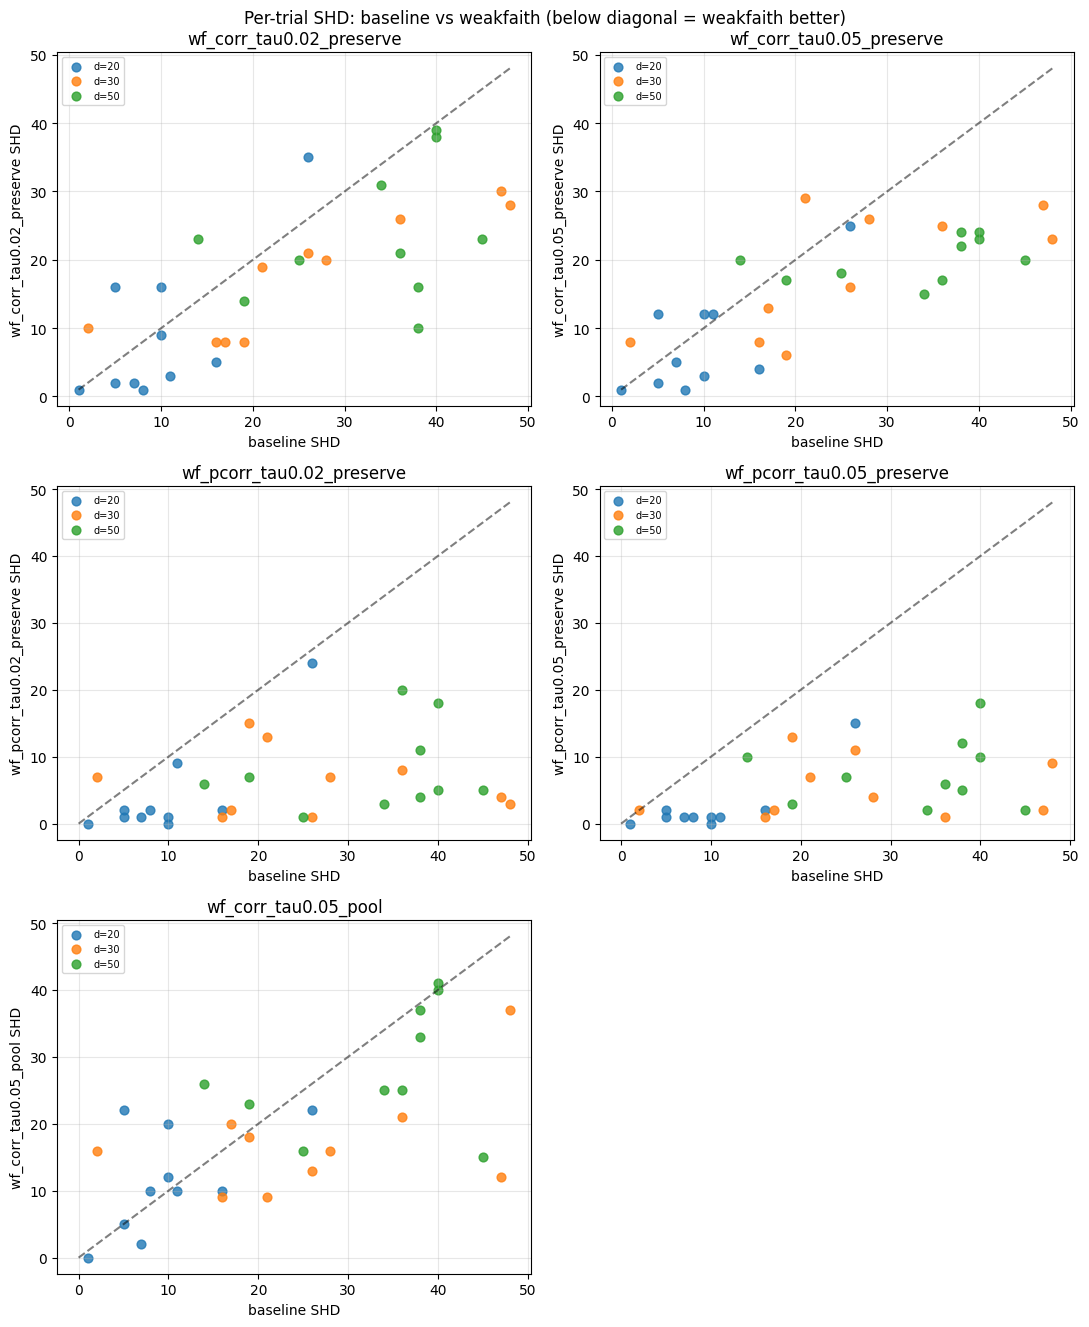

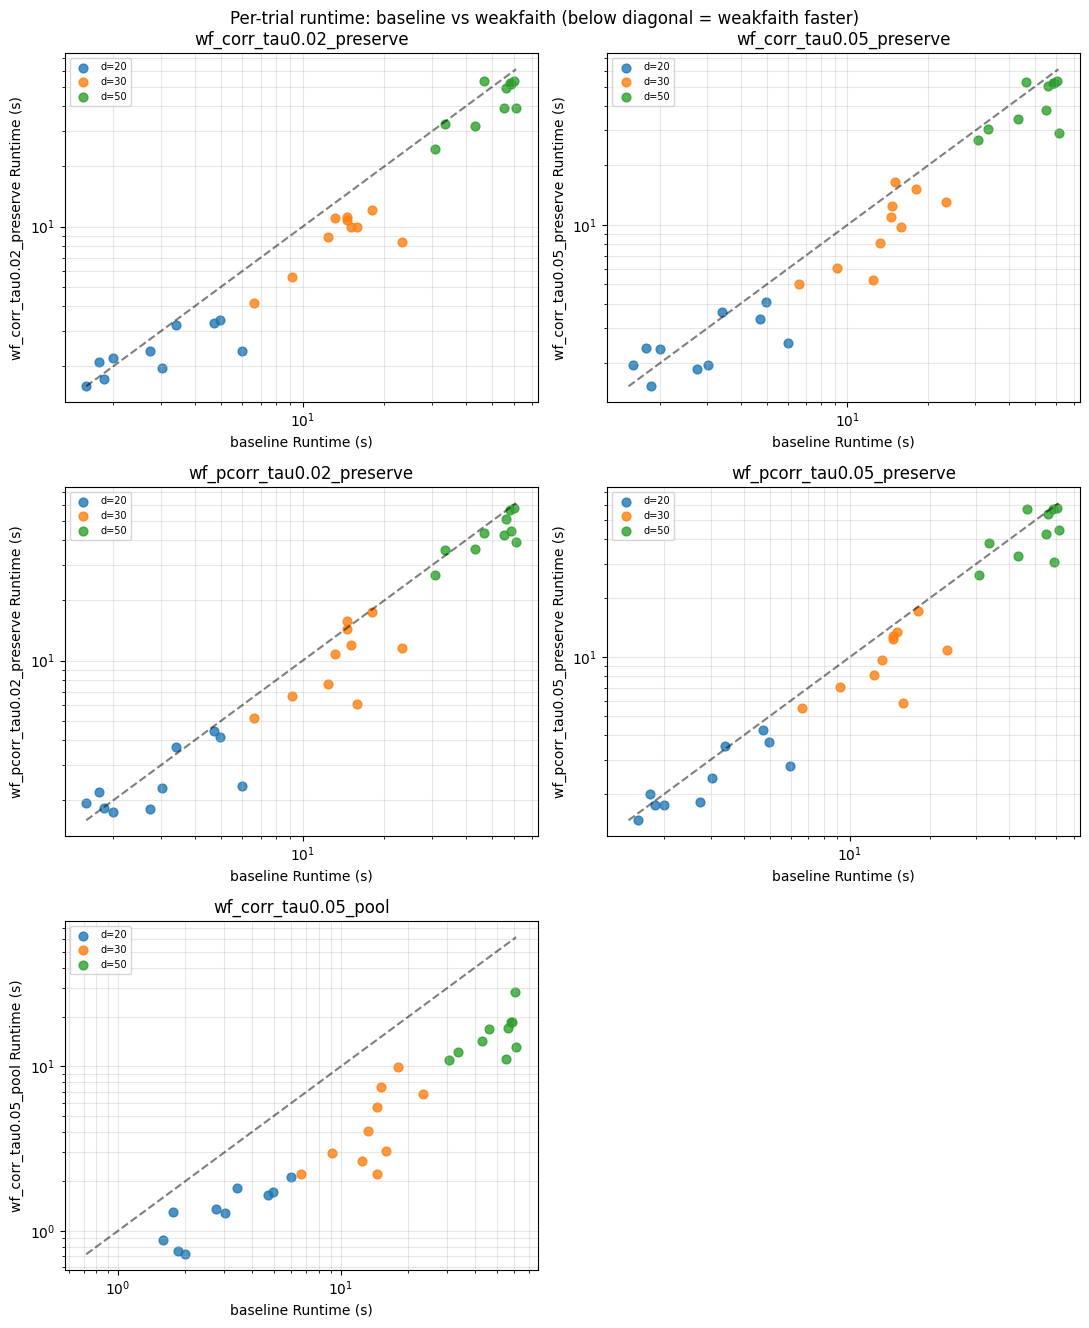

In [10]:
# 8) Per-trial paired scatter: baseline vs each weakfaith variant
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    baseline_label = 'baseline'
    wf_labels = [v['label'] for v in VARIANTS if v['kind'] == 'weakfaith'
                 and v['label'] in df_trials['algorithm'].unique()]

    if baseline_label not in df_trials['algorithm'].unique():
        print('Baseline missing; skipping paired scatters.')
    else:
        pivot_shd = df_trials.pivot_table(
            index=['d', 'n_samples', 'trial_id'], columns='algorithm', values='shd').reset_index()
        pivot_rt = df_trials.pivot_table(
            index=['d', 'n_samples', 'trial_id'], columns='algorithm', values='runtime_sec').reset_index()

        n_cols = 2
        n_rows = (len(wf_labels) + n_cols - 1) // n_cols
        for metric_name, pivot, title, log_axes in [
            ('SHD', pivot_shd, 'Per-trial SHD: baseline vs weakfaith (below diagonal = weakfaith better)', False),
            ('Runtime (s)', pivot_rt, 'Per-trial runtime: baseline vs weakfaith (below diagonal = weakfaith faster)', True),
        ]:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * n_rows), squeeze=False)
            for i, wf in enumerate(wf_labels):
                ax = axes[i // n_cols][i % n_cols]
                if wf not in pivot.columns:
                    ax.set_visible(False)
                    continue
                xs = pivot[baseline_label].values
                ys = pivot[wf].values
                ds = pivot['d'].values
                for di, d_val in enumerate(sorted(np.unique(ds))):
                    mask = ds == d_val
                    ax.scatter(xs[mask], ys[mask], s=40, alpha=0.8,
                               label=f'd={d_val}', color=f'C{di}')
                lo = np.nanmin(np.concatenate([xs, ys]))
                hi = np.nanmax(np.concatenate([xs, ys]))
                if log_axes:
                    ax.set_xscale('log'); ax.set_yscale('log')
                    lo = max(lo, 1e-3)
                ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
                ax.set_xlabel(f'baseline {metric_name}')
                ax.set_ylabel(f'{wf} {metric_name}')
                ax.set_title(wf)
                ax.grid(True, alpha=0.3, which='both')
                ax.legend(fontsize=7)
            for j in range(len(wf_labels), n_rows * n_cols):
                axes[j // n_cols][j % n_cols].set_visible(False)
            fig.suptitle(title, fontsize=12)
            plt.tight_layout()
            plt.show()

Mean mask keep ratio (M / d(d-1)) across trials:


algorithm,wf_corr_tau0.02_preserve,wf_corr_tau0.05_pool,wf_corr_tau0.05_preserve,wf_pcorr_tau0.02_preserve,wf_pcorr_tau0.05_preserve
d,,,,,
20,0.283158,0.272632,0.272632,0.176842,0.170000
30,0.250805,0.247126,0.247126,0.122299,0.118161
50,0.146204,0.139102,0.139102,0.068082,0.063918


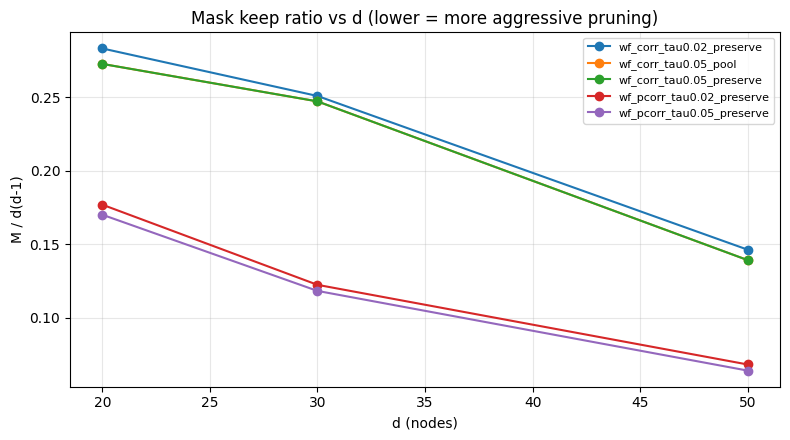

In [11]:
# 9) Mask sparsity diagnostic: M / d(d-1) across variants and d
if 'mask_keep_ratio' not in df_trials.columns:
    print('No mask_keep_ratio column.')
else:
    wf_sub = df_trials[df_trials['algorithm'] != 'baseline']
    pivot = wf_sub.pivot_table(
        index='d', columns='algorithm', values='mask_keep_ratio', aggfunc='mean',
    )
    print('Mean mask keep ratio (M / d(d-1)) across trials:')
    display(pivot)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for alg in pivot.columns:
        ax.plot(pivot.index, pivot[alg], marker='o', label=alg)
    ax.set_xlabel('d (nodes)')
    ax.set_ylabel('M / d(d-1)')
    ax.set_title('Mask keep ratio vs d (lower = more aggressive pruning)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# 10) Skip log
if skip_logs:
    display(pd.DataFrame(skip_logs))
else:
    print('No skips.')

No skips.


: 